# Food Delivery Time Forecast Project

This project focuses on predicting end-to-end food delivery times using advanced regression modeling. To replace basic distance-based estimates with data-driven insights, the model evaluates courier dynamics, traffic congestion, and weather impacts simultaneously. With a strong emphasis on feature engineering—such as geospatial indexing and environmental data representation—this tool aims to empower logistics platforms with accurate timing forecasts, streamlined dispatch decisions, and better customer experiences.

<img src='https://totalfood.com/wp-content/uploads/2023/04/Restaurant-Online-Food-Delivery-1.webp' width='750'>

In [1]:
#Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')

### EDA

In [2]:
df=pd.read_csv('Food_Delivery_Times.csv')

In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [5]:
df.shape

(1000, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [7]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [8]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [9]:
df.corr(numeric_only=True)

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Order_ID,1.000000,-0.024483,-0.035100,0.013152,-0.036650
Distance_km,-0.024483,1.000000,-0.009037,-0.007842,0.780998
Preparation_Time_min,-0.035100,-0.009037,1.000000,-0.030830,0.307350
Courier_Experience_yrs,0.013152,-0.007842,-0.030830,1.000000,-0.090433
Delivery_Time_min,-0.036650,0.780998,0.307350,-0.090433,1.000000


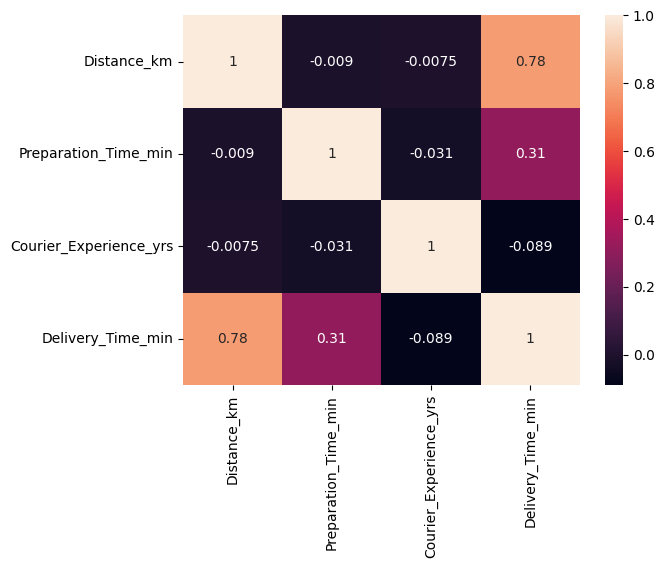

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True);

In [10]:
df = df.drop('Order_ID', axis=1)

In [12]:
# Handling Missing Values (Imputation)

df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [16]:
# Encoding Categorical Variables
le = LabelEncoder()
cat_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [18]:
df.isnull().sum()

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [17]:
abs(df.corr(numeric_only=True)['Delivery_Time_min'].sort_values(ascending=False))

Delivery_Time_min         1.000000
Distance_km               0.780998
Preparation_Time_min      0.307350
Weather                   0.132867
Time_of_Day               0.000998
Vehicle_Type              0.006629
Courier_Experience_yrs    0.089111
Traffic_Level             0.102813
Name: Delivery_Time_min, dtype: float64

<Axes: title={'center': 'Distance vs Delivery Time'}, xlabel='Distance_km', ylabel='Delivery_Time_min'>

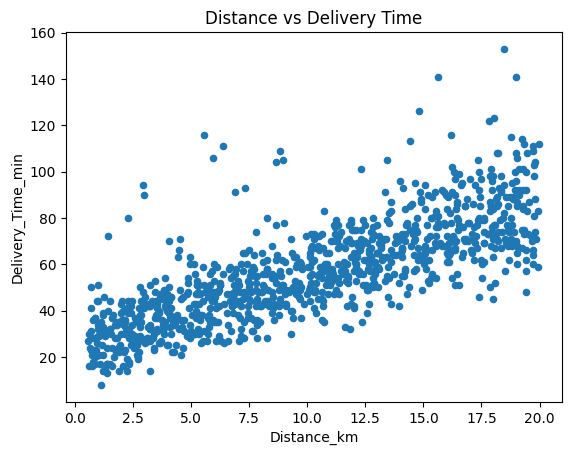

In [19]:
# Relationship between distance and delivery time
df.plot.scatter(x='Distance_km', y='Delivery_Time_min', title='Distance vs Delivery Time')

<Axes: title={'center': 'Average Delivery Time by Vehicle Type'}, xlabel='Vehicle_Type'>

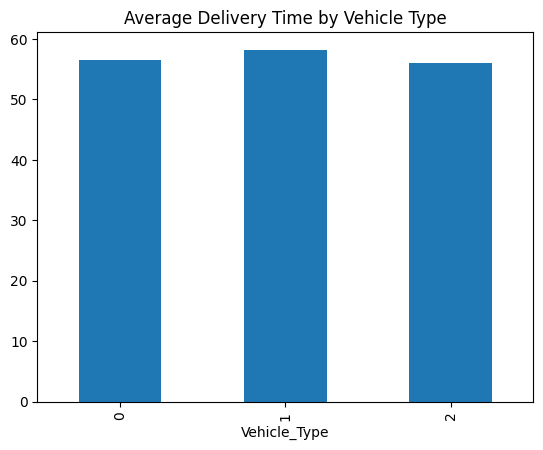

In [20]:
# Average delivery time grouped by vehicle type
df.groupby('Vehicle_Type')['Delivery_Time_min'].mean().plot.bar(title='Average Delivery Time by Vehicle Type')

<Axes: title={'center': 'Delivery Time Distribution'}, ylabel='Frequency'>

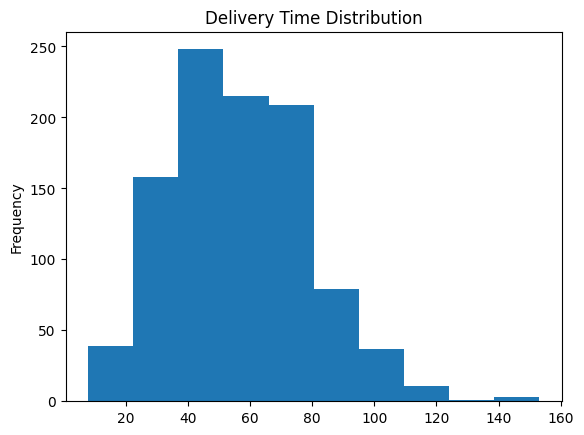

In [21]:
# Distribution of delivery times
df['Delivery_Time_min'].plot.hist(bins=10, title='Delivery Time Distribution')

<Axes: title={'center': 'Order Count by Time of Day'}, xlabel='Time_of_Day'>

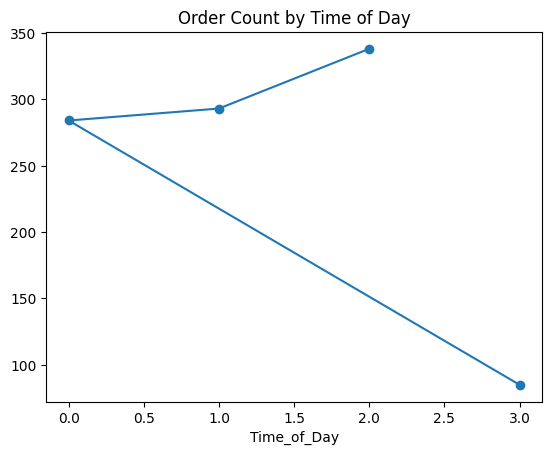

In [22]:
# Number of orders per time of day
df['Time_of_Day'].value_counts().plot.line(marker='o', title='Order Count by Time of Day')

### Modeling 

In [24]:
x= df.drop(['Delivery_Time_min'], axis=1)

In [25]:
y = df['Delivery_Time_min']

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
lr=LinearRegression()

In [30]:
model=lr.fit(x_train,y_train)

In [31]:
prediction=model.predict(x_test)

In [32]:
from sklearn.metrics import r2_score,mean_squared_error 

In [33]:
r2_score(y_test,prediction)

0.7563435950951675

In [34]:
mean_squared_error(y_test,prediction)**.5

10.450520241110882

In [35]:
residuals= y_test-prediction

In [36]:
residuals

521   -8.169177
737    3.912937
740    0.573278
660    2.252205
411   -1.201031
         ...   
408    0.383823
332   -0.110093
208    5.062656
613   -3.060221
78     3.378645
Name: Delivery_Time_min, Length: 200, dtype: float64

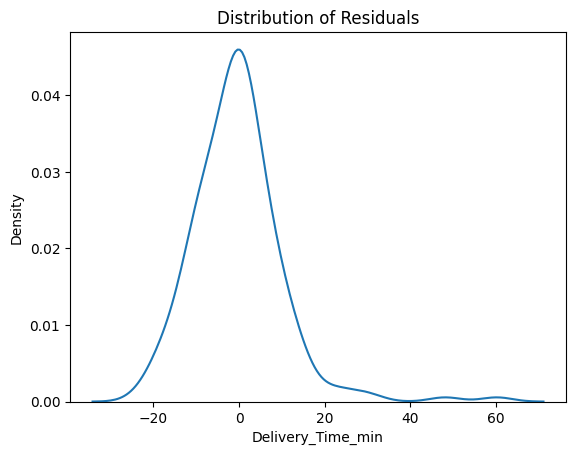

In [38]:
# If residuals is a Series or Array
sns.kdeplot(residuals)
plt.title('Distribution of Residuals')
plt.show()

In [39]:
from yellowbrick.regressor import ResidualsPlot

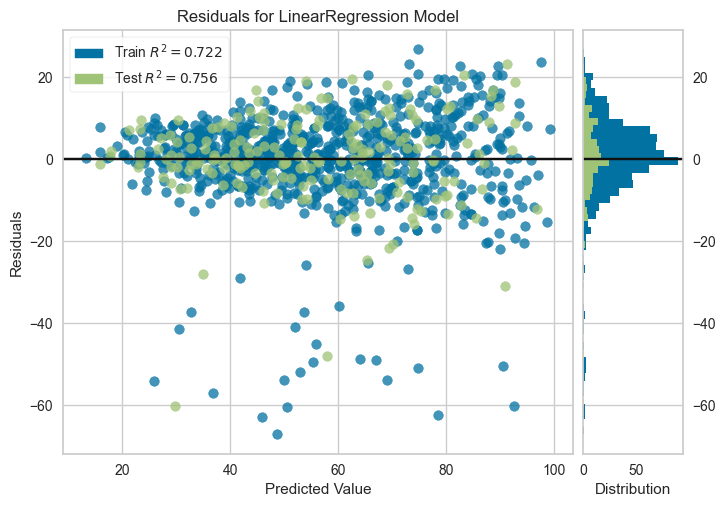

In [40]:
vis=ResidualsPlot(lr)
vis.fit(x_train,y_train)
vis.score(x_test,y_test)
vis.show()
plt.show()

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
# pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


def algo_test(x, y):
    # Defining all models
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor()
    rkn = RadiusNeighborsRegressor(radius=1.0)
    ada = AdaBoostRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor()
    svr = SVR()
    mlp_regressor = MLPRegressor()

    algos = [L, R, Lass, E, sgd, ETR, GBR, ada, kn, dt, xgb, svr, mlp_regressor]
    algo_names = [
        "Linear",
        "Ridge",
        "Lasso",
        "ElasticNet",
        "SGD",
        "Extra Tree",
        "Gradient Boosting",
        "KNeighborsRegressor",
        "AdaBoost",
        "Decision Tree",
        "XGBRegressor",
        "SVR",
        "mlp_regressor",
    ]

    x = MinMaxScaler().fit_transform(x)
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.20, random_state=42
    )

    r_squared = []
    rmse = []
    mae = []

    # Creating a dataframe to compile error rates and performance metrics into a table
    result = pd.DataFrame(columns=["R_Squared", "RMSE", "MAE"], index=algo_names)

    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        r_squared.append(r2_score(y_test, p))
        rmse.append(mean_squared_error(y_test, p) ** 0.5)
        mae.append(mean_absolute_error(y_test, p))

    # Inserting the metrics into the result table
    result.R_Squared = r_squared
    result.RMSE = rmse
    result.MAE = mae

    # Sorting the result table by R_Squared in descending order and returning it
    rtable = result.sort_values("R_Squared", ascending=False)
    return rtable

In [42]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.807737,9.283176,6.514876
Ridge,0.756779,10.441189,7.288479
SGD,0.756651,10.443922,7.303202
Linear,0.756344,10.450520,7.286671
XGBRegressor,0.748326,10.621064,7.725087
SVR,0.695169,11.689024,8.409282
Lasso,0.692427,11.741479,8.721014
AdaBoost,0.663053,12.289378,9.362000
Decision Tree,0.562889,13.997321,9.935000
KNeighborsRegressor,0.463823,15.502551,13.416302


In [44]:
model.coef_

array([ 3.01471567,  1.45905485, -1.76247183, -0.24610898, -0.27178973,
        0.97508693, -0.67432103])

In [45]:
fi=pd.DataFrame({'Feature':x_train.columns,'Coefs':model.coef_[0]})

In [46]:
fi

,Feature,Coefs
0,Distance_km,3.014716
1,Weather,3.014716
2,Traffic_Level,3.014716
3,Time_of_Day,3.014716
4,Vehicle_Type,3.014716
5,Preparation_Time_min,3.014716
6,Courier_Experience_yrs,3.014716


<BarContainer object of 7 artists>

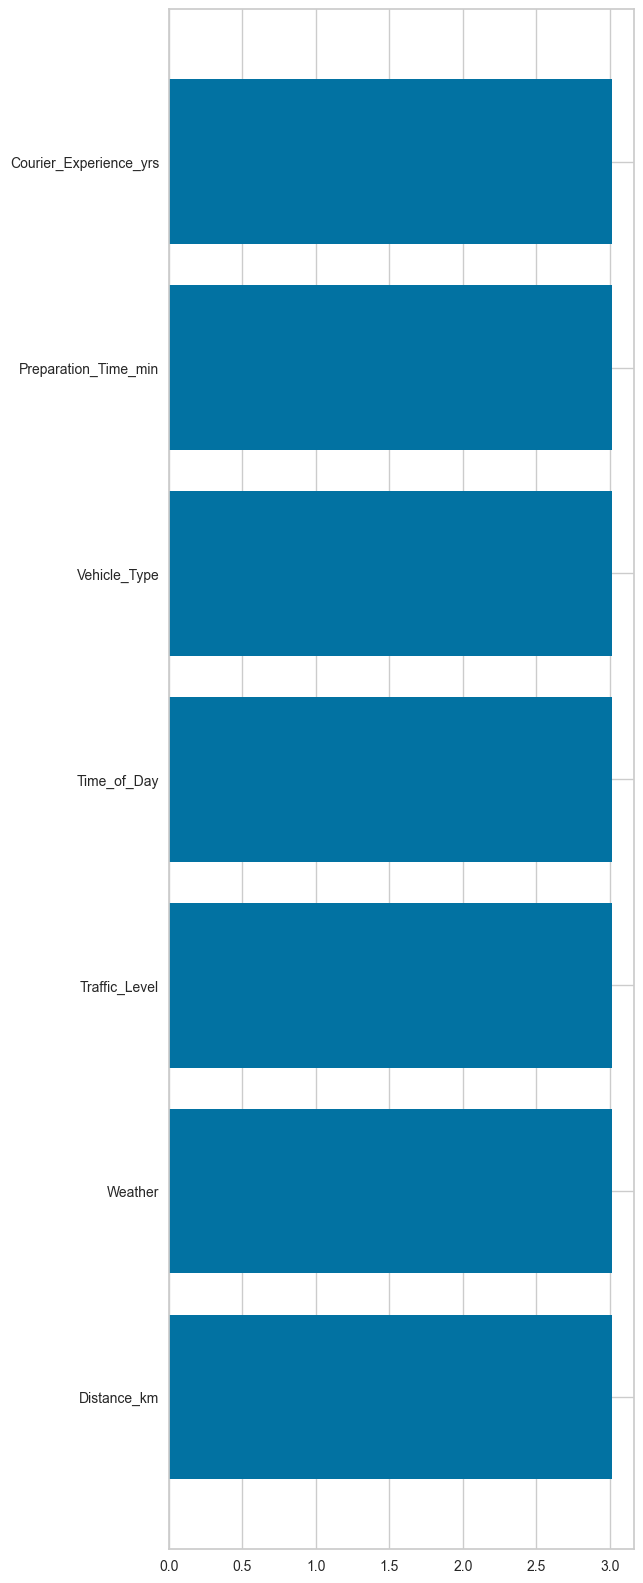

In [47]:
plt.figure(figsize=(6,20))
plt.barh(fi['Feature'],fi['Coefs'])

Gradient Boosting Regressor emerged as the best-performing model, demonstrating superior predictive power with an $R^2$ score of 0.8077 and an MAE of 6.51 minutes.